In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. 基礎設定 ---
# 定義 Q1~Q4 對應的固定顏色
qubit_colors = {
    "Q1": '#9bbf8a',
    "Q2": '#92afda',
    "Q3": '#f79059',
    "Q4": '#c82423'
}

temperatures = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 125, 130, 140,145, 150,155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 210] # mK

qubits_to_plot = ["Q1",  "Q3", "Q4"]
qubit_frequency = [3620.63506, 4029.170438, 3127.600198, 3311.82327] # MHz
all_data = []


成功讀取: qubit_results_10mK.csv
成功讀取: qubit_results_20mK.csv
成功讀取: qubit_results_30mK.csv
成功讀取: qubit_results_40mK.csv
成功讀取: qubit_results_50mK.csv
成功讀取: qubit_results_60mK.csv
成功讀取: qubit_results_70mK.csv
成功讀取: qubit_results_80mK.csv
成功讀取: qubit_results_90mK.csv
成功讀取: qubit_results_100mK.csv
成功讀取: qubit_results_110mK.csv
成功讀取: qubit_results_120mK.csv
成功讀取: qubit_results_125mK.csv
成功讀取: qubit_results_130mK.csv
成功讀取: qubit_results_140mK.csv
成功讀取: qubit_results_145mK.csv
成功讀取: qubit_results_150mK.csv
成功讀取: qubit_results_155mK.csv
成功讀取: qubit_results_160mK.csv
成功讀取: qubit_results_165mK.csv
成功讀取: qubit_results_170mK.csv
成功讀取: qubit_results_175mK.csv
成功讀取: qubit_results_180mK.csv
成功讀取: qubit_results_185mK.csv
成功讀取: qubit_results_190mK.csv
成功讀取: qubit_results_195mK.csv
成功讀取: qubit_results_200mK.csv
成功讀取: qubit_results_210mK.csv


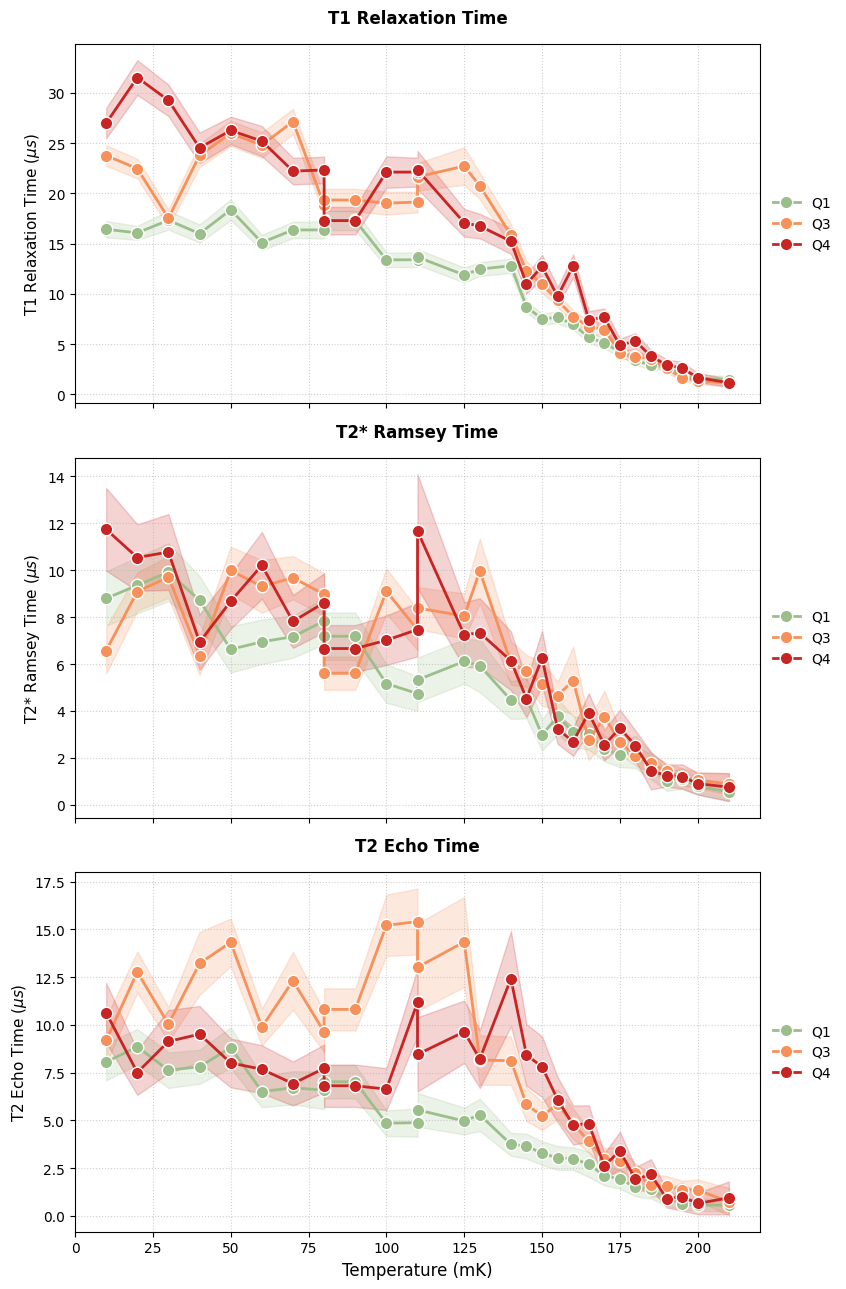

In [104]:

# --- 2. 讀取數據 ---
for temp in temperatures:
    file_path = f"qubit_results_{temp}mK.csv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        if not df.empty:
            all_data.append(df)
            print(f"成功讀取: {file_path}")
    else:
        print(f"找不到檔案: {file_path}")

if len(all_data) == 0:
    print("❌ 錯誤：沒有讀取到任何數據！")
else:
    df_total = pd.concat(all_data, ignore_index=True)

    # --- 3. 開始繪圖 ---
    # 定義子圖指標 (欄位名, 誤差欄位名, 顯示標題)
    metrics = [
        ('t1_time', 't1_err', 'T1 Relaxation Time'),
        ('t2r_time', 't2r_err', 'T2* Ramsey Time'),
        ('t2e_time', 't2e_err', 'T2 Echo Time')
    ]

    fig, axes = plt.subplots(len(metrics), 1, figsize=(9, 13), sharex=True)

    for i, (val_col, err_col, title) in enumerate(metrics):
        ax = axes[i]
        
        for q in qubits_to_plot:
            # 挑選資料
            q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
            if q_df.empty:
                continue

            # 取得該 Qubit 專屬顏色
            q_color = qubit_colors.get(q, '#000000') # 預設黑色
            
            # 轉換數據格式
            temp_x = q_df['temp_mK'].values
            y_vals = pd.to_numeric(q_df[val_col], errors='coerce').values
            y_errs = pd.to_numeric(q_df[err_col], errors='coerce').fillna(0).values
            
            # 畫出 Qubit 的中心線與點
            ax.plot(temp_x, y_vals, 'o-', label=f'{q}', color=q_color, 
                    markersize=9, linewidth=2, markeredgecolor='white', markeredgewidth=1)
            
            # 畫出 Qubit 的 Error Band (誤差帶)
            ax.fill_between(temp_x, y_vals - y_errs, y_vals + y_errs, 
                            color=q_color, alpha=0.2)

        # 子圖美化
        ax.set_ylabel(f"{title} ($\mu s$)", fontsize=11)
        ax.set_title(title, fontweight='bold', pad=15)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False) # 標籤放在右側

    axes[-1].set_xlabel("Temperature (mK)", fontsize=12)
    
    # 調整間距以容納右側 Legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.85) 
    plt.show()

<Figure size 1000x700 with 0 Axes>

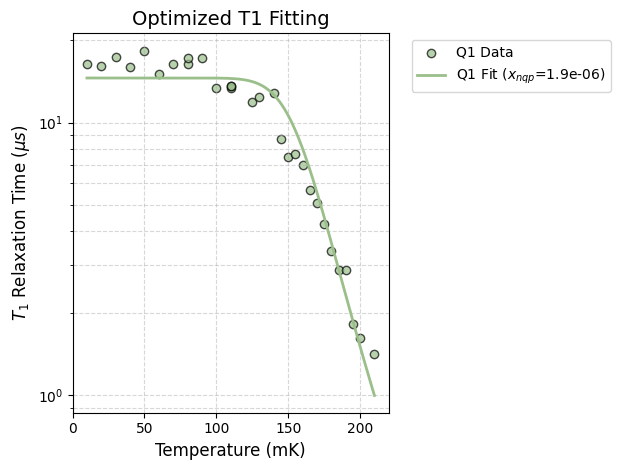

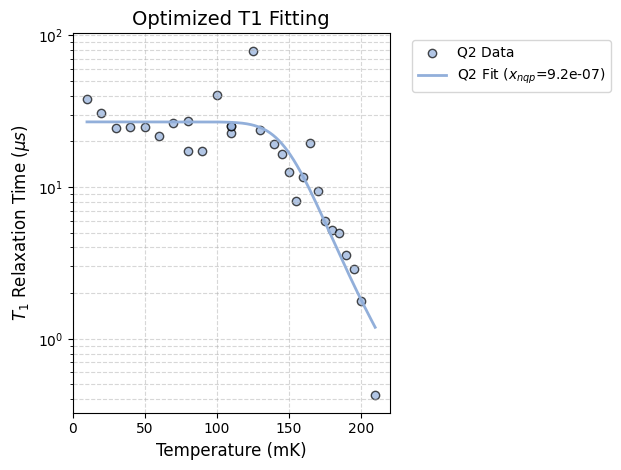

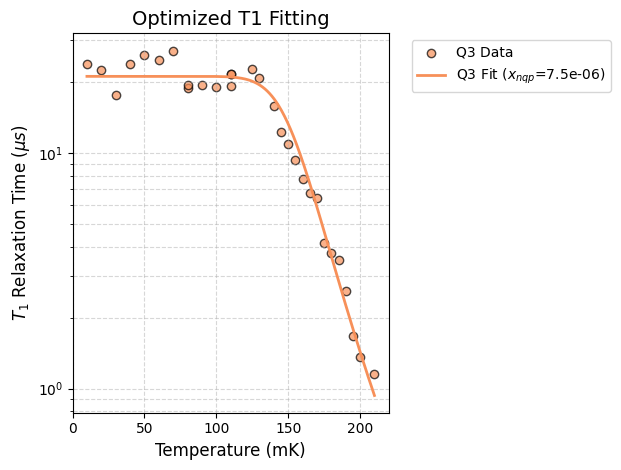

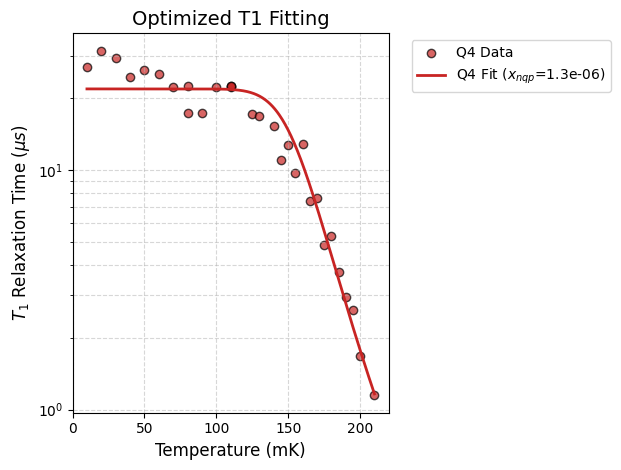

[Q1 Fit Results]
  Optimized x_nqp : 1.33e-06
  Current n_qp   : 8.2505 μm⁻³
  T1 Limit (T->0): 21.8 us
  T2 Limit (T->0): 20.2 us
----------------------------------------
[Q2 Fit Results]
  Optimized x_nqp : 1.33e-06
  Current n_qp   : 8.2505 μm⁻³
  T1 Limit (T->0): 21.8 us
  T2 Limit (T->0): 19.2 us
----------------------------------------
[Q3 Fit Results]
  Optimized x_nqp : 1.33e-06
  Current n_qp   : 8.2505 μm⁻³
  T1 Limit (T->0): 21.8 us
  T2 Limit (T->0): 21.6 us
----------------------------------------
[Q4 Fit Results]
  Optimized x_nqp : 1.33e-06
  Current n_qp   : 8.2505 μm⁻³
  T1 Limit (T->0): 21.8 us
  T2 Limit (T->0): 21.1 us
----------------------------------------


In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- 1. 物理常數 ---
qubit_colors = {"Q1": '#9bbf8a', "Q2": '#92afda', "Q3": '#f79059', "Q4": '#c82423'}
qubit_freqs = {"Q1": 3620.6, "Q2": 4029.1, "Q3": 3127.6, "Q4": 3311.8} 
EC = 200 
DELTA_KB = 1800 
DELTA_UEV = 180 

def qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    # 增加 epsilon 防止 T=0 報錯
    T = np.maximum(T, 1e-6)
    term_sqrt = np.sqrt(2 * np.pi * T / DELTA_KB)
    term_exp = np.exp(-DELTA_KB / T)
    x_qp = x_nqp + term_sqrt * term_exp
    return Gamma_bg + scale_factor * x_qp


def log_qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    return np.log10(qp_rate_model(T, Gamma_bg, scale_factor, x_nqp))

# --- 2. 核心分析與繪圖 ---
plt.figure(figsize=(10, 7))

for q in ["Q1", "Q2", "Q3", "Q4"]:
    q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
    if q_df.empty: continue
    
    T_data = q_df['temp_mK'].values
    T1_data = q_df['t1_time'].values
    rate_data = 1 / T1_data
    log_rate_data = np.log10(rate_data)
    
    try:
        # 優化點 1: 更精確的初始猜測
        # Gamma_bg 猜測最低溫度的速率
        g_bg_init = rate_data.min()
        # scale_factor 理論值大約在 10^2 ~ 10^3 之間
        
        # 優化點 2: 使用對數擬合以提高低溫段準確度
        popt, _ = curve_fit(log_qp_rate_model, T_data, log_rate_data, 
                            p0=[g_bg_init, 800, 1e-7], 
                            bounds=([0, 1, 1e-10], [1, 1e5, 1e-4]),
                            maxfev=10000)
        
        g_bg, s_fit, x_nqp_fit = popt
        plt.figure()
        # 繪圖
        plt.scatter(T_data, T1_data, color=qubit_colors[q], label=f'{q} Data', alpha=0.7, edgecolors='k')
        T_fit = np.linspace(T_data.min(), T_data.max(), 500)
        rate_fit = qp_rate_model(T_fit, *popt)
        plt.plot(T_fit, 1/rate_fit, '-', color=qubit_colors[q], linewidth=2,
                 label=f'{q} Fit ($x_{{nqp}}$={x_nqp_fit:.1e})')
        
        # --- 計算 T2 Limit ---
        f_ge = qubit_freqs[q]
        wp = f_ge + EC
        t1_limit = 1 / qp_rate_model(1e-6, *popt) # 近似 T=0
        gamma_phi_nqp = (np.pi / 4) * f_ge * (wp / f_ge)**2 * x_nqp_fit
        rate_t2_limit = (1 / (2 * t1_limit)) + (2 * np.pi * gamma_phi_nqp)
        t2_limit = 1 / rate_t2_limit
        
    except Exception as e:
        print(f"{q} Fitting Error: {e}")

    plt.yscale('log')
    plt.xlabel("Temperature (mK)", fontsize=12)
    plt.ylabel("$T_1$ Relaxation Time ($\mu s$)", fontsize=12)
    plt.title("Optimized T1 Fitting", fontsize=14)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



N0_AL = 1.72e10   # 1/eV/um^3
DELTA_EV = 180e-6 # 180 ueV 轉為 eV

for q in ["Q1", "Q2", "Q3", "Q4"]:
    try:
        g_bg, s_fit, x_nqp_fit = popt
        n_qp_current = 2 * N0_AL * DELTA_EV * x_nqp_fit
        # --- 計算 T2 Limit ---
        f_ge = qubit_freqs[q]
        wp = f_ge + EC
        t1_limit = 1 / qp_rate_model(1e-6, *popt) 
        gamma_phi_nqp = (np.pi / 4) * f_ge * (wp / f_ge)**2 * x_nqp_fit
        rate_t2_limit = (1 / (2 * t1_limit)) + (2 * np.pi * gamma_phi_nqp)
        t2_limit = 1 / rate_t2_limit

        print(f"[{q} Fit Results]")
        print(f"  Optimized x_nqp : {x_nqp_fit:.2e}")
        print(f"  Current n_qp   : {n_qp_current:.4f} μm⁻³") # <-- 新增這行
        print(f"  T1 Limit (T->0): {t1_limit:.1f} us")
        print(f"  T2 Limit (T->0): {t2_limit:.1f} us")
        print("-" * 40)
        
    except Exception as e:
        print(f"{q} Fitting Error: {e}")


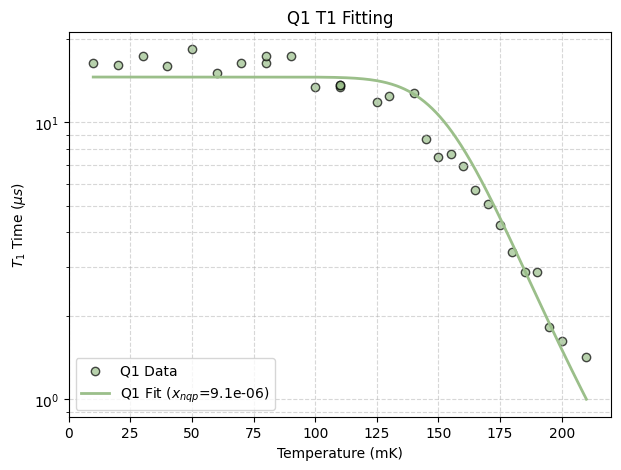

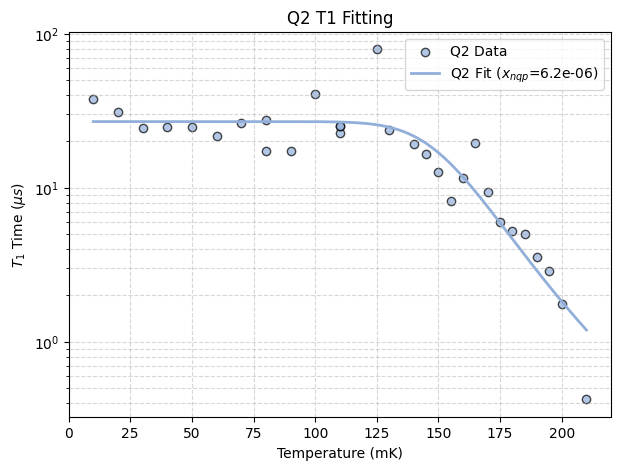

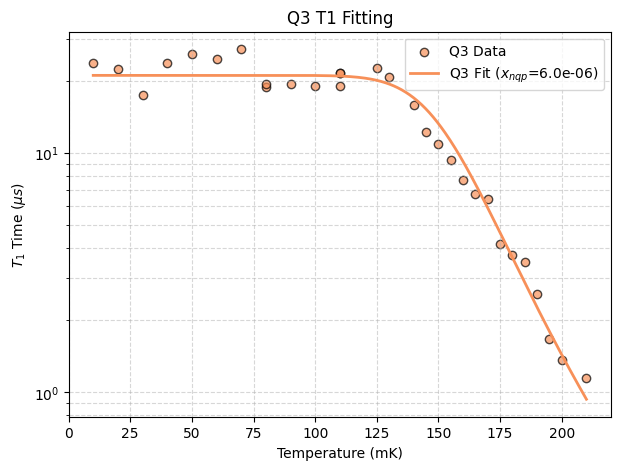

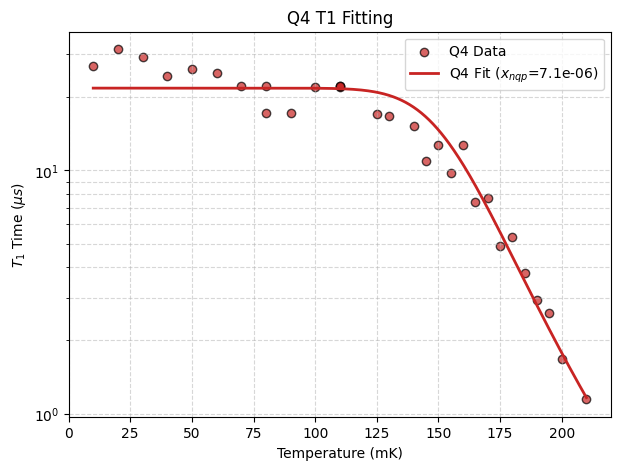


Qubit    | Fit x_nqp    | T1_pred (μs)  | T2_pred (μs) 
         |              | (@20mK)       | (@20mK)      
----------------------------------------------------------------------
Note: Predictions assume ideal x_nqp = 5.00e-08 and temperature = 20 mK
Q1       | 9.10e-06     | 60.2          | 107.5        
Q2       | 6.21e-06     | 150.6         | 226.5        
Q3       | 5.95e-06     | 98.4          | 168.0        
Q4       | 7.07e-06     | 94.1          | 160.5        


In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- 1. 物理常數與模型 ---
qubit_colors = {"Q1": '#9bbf8a', "Q2": '#92afda', "Q3": '#f79059', "Q4": '#c82423'}
qubit_freqs = {"Q1": 3620.6, "Q2": 4029.1, "Q3": 3127.6, "Q4": 3311.8} 
EC = 200 
DELTA_KB = 1800 
N0_AL = 1.72e10   # 1/eV/um^3
DELTA_EV = 180e-6 # eV

def qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    T = np.maximum(T, 1e-6)
    term_sqrt = np.sqrt(2 * np.pi * T / DELTA_KB)
    term_exp = np.exp(-DELTA_KB / T)
    x_qp = x_nqp + term_sqrt * term_exp
    return Gamma_bg + scale_factor * x_qp

def log_qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    # 使用對數擬合對低溫數據更敏感
    return np.log10(qp_rate_model(T, Gamma_bg, scale_factor, x_nqp))

# --- 2. 核心分析與繪圖 ---
fit_results_dict = {} 

for q in ["Q1", "Q2", "Q3", "Q4"]:
    q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
    if q_df.empty: continue
    
    T_data = q_df['temp_mK'].values
    T1_data = q_df['t1_time'].values
    rate_data = 1 / T1_data
    log_rate_data = np.log10(rate_data)
    
    try:
        # --- [優化核心]：自動推導初始值與邊界 ---
        # 取得數據中的最低速率 (通常發生在最低溫)
        min_observed_rate = rate_data.min()
        
        # 1. Gamma_bg 初始猜測：假設一半的低溫速率來自背景
        g_bg_init = min_observed_rate * 0.5
        
        # 2. scale_factor 初始猜測：根據高溫段斜率大致估算 (通常在 500-1500 間)
        s_init = 1000 
        
        # 3. x_nqp 初始猜測：根據剩下的另一半速率回推
        x_nqp_init = (min_observed_rate * 0.5) / s_init

        # 設定嚴格邊界：Gamma_bg 絕不能超過目前觀測到的總速率
        # 這樣擬合器就不會無腦把所有衰減都丟給背景，而忽略準粒子
        lower_bounds = [0, 10, 1e-12]
        upper_bounds = [min_observed_rate * 1.1, 1e5, 1e-4]

        popt, pcov = curve_fit(
            log_qp_rate_model, T_data, log_rate_data, 
            p0=[g_bg_init, s_init, x_nqp_init], 
            bounds=(lower_bounds, upper_bounds),
            maxfev=50000
        )
        
        fit_results_dict[q] = popt
        g_bg, s_fit, x_nqp_fit = popt
        
        # 繪圖
        plt.figure(figsize=(7, 5))
        plt.scatter(T_data, T1_data, color=qubit_colors[q], label=f'{q} Data', alpha=0.7, edgecolors='k')
        T_fit = np.linspace(T_data.min(), T_data.max(), 500)
        rate_fit_vals = qp_rate_model(T_fit, *popt)
        plt.plot(T_fit, 1/rate_fit_vals, '-', color=qubit_colors[q], linewidth=2,
                 label=f'{q} Fit ($x_{{nqp}}$={x_nqp_fit:.1e})')
        
        plt.yscale('log')
        plt.xlabel("Temperature (mK)")
        plt.ylabel("$T_1$ Time ($\mu s$)")
        plt.title(f"{q} T1 Fitting")
        plt.grid(True, which="both", ls="--", alpha=0.5)
        plt.legend()
        plt.show()
        
    except Exception as e:
        print(f"{q} Fitting Error: {e}")

# --- 3. 預測功能 ---
def predict_qubit_performance(target_q, ideal_temp_mK, ideal_x_nqp):
    if target_q not in fit_results_dict:
        return None
    
    g_bg, s_fit, _ = fit_results_dict[target_q]
    f_ge = qubit_freqs[target_q]
    wp = f_ge + EC
    
    # 理想總 x_qp
    term_sqrt = np.sqrt(2 * np.pi * ideal_temp_mK / DELTA_KB)
    term_exp = np.exp(-DELTA_KB / ideal_temp_mK)
    x_qp_total = ideal_x_nqp + term_sqrt * term_exp
    
    # 預測 T1 與 T2
    rate_t1 = g_bg + s_fit * x_qp_total
    t1_pred = 1 / rate_t1
    gamma_phi_qp = (np.pi / 4) * f_ge * (wp / f_ge)**2 * x_qp_total
    rate_t2 = (1 / (2 * t1_pred)) + (2 * np.pi * gamma_phi_qp)
    
    return {"T1": t1_pred, "T2": 1/rate_t2, "n_qp": 2 * N0_AL * DELTA_EV * ideal_x_nqp}

# --- 4. 輸出與手動預測 ---
IDEAL_X_NQP = 5e-8 
IDEAL_TEMP = 20 

print("\n" + "="*70)
print(f"{'Qubit':<8} | {'Fit x_nqp':<12} | {'T1_pred (μs)':<13} | {'T2_pred (μs)':<13}")
print(f"{'':<8} | {'':<12} | {'(@' + str(IDEAL_TEMP) + 'mK)':<13} | {'(@' + str(IDEAL_TEMP) + 'mK)':<13}")
print("-" * 70)
print(f"Note: Predictions assume ideal x_nqp = {IDEAL_X_NQP:.2e} and temperature = {IDEAL_TEMP} mK")
for q in ["Q1", "Q2", "Q3", "Q4"]:
    if q in fit_results_dict:
        popt = fit_results_dict[q]
        pred = predict_qubit_performance(q, IDEAL_TEMP, IDEAL_X_NQP)
        print(f"{q:<8} | {popt[2]:.2e}     | {pred['T1']:<13.1f} | {pred['T2']:<13.1f}")

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- 1. 物理常數與換算因子 ---
qubit_colors = {"Q1": '#9bbf8a', "Q2": '#92afda', "Q3": '#f79059', "Q4": '#c82423'}
qubit_freqs = {"Q1": 3620.6, "Q2": 4029.1, "Q3": 3127.6, "Q4": 3311.8} 
EC = 200 
DELTA_KB = 1800 
# 鋁的換算因子: n_qp = x_qp * (2 * N0 * Delta)
# 根據 Barends (2011), 2 * N0 * Delta 約為 6.19e6 um^-3
NQP_CONV = 6.192e6 

def qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    T = np.maximum(T, 1e-6)
    term_sqrt = np.sqrt(2 * np.pi * T / DELTA_KB)
    term_exp = np.exp(-DELTA_KB / T)
    x_qp = x_nqp + term_sqrt * term_exp
    return Gamma_bg + scale_factor * x_qp

def log_qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    return np.log10(qp_rate_model(T, Gamma_bg, scale_factor, x_nqp))

# --- 2. 核心分析與繪圖 ---
fit_results_dict = {} 

for q in ["Q1", "Q2", "Q3", "Q4"]:
    q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
    if q_df.empty: continue
    
    T_data = q_df['temp_mK'].values
    T1_data = q_df['t1_time'].values
    rate_data = 1 / T1_data
    
    try:
        min_observed_rate = rate_data.min()
        g_bg_init = min_observed_rate * 0.5
        s_init = 1000 
        x_nqp_init = (min_observed_rate * 0.5) / s_init

        lower_bounds = [0, 10, 1e-12]
        upper_bounds = [min_observed_rate * 1.1, 1e5, 1e-4]

        popt, _ = curve_fit(
            log_qp_rate_model, T_data, np.log10(rate_data), 
            p0=[g_bg_init, s_init, x_nqp_init], 
            bounds=(lower_bounds, upper_bounds),
            maxfev=50000
        )
        fit_results_dict[q] = popt
        
    except Exception as e:
        print(f"{q} Fitting Error: {e}")

# --- 3. 預測功能 (帶入 n_qp 計算) ---
def predict_performance(target_q, ideal_temp_mK, ideal_x_nqp):
    if target_q not in fit_results_dict: return None
    g_bg, s_fit, _ = fit_results_dict[target_q]
    f_ge = qubit_freqs[target_q]
    wp = f_ge + EC
    
    # 理想總 x_qp 與 n_qp
    term_sqrt = np.sqrt(2 * np.pi * ideal_temp_mK / DELTA_KB)
    term_exp = np.exp(-DELTA_KB / ideal_temp_mK)
    x_qp_total = ideal_x_nqp + term_sqrt * term_exp

    # 預測 T1/T2
    t1_pred = 1 / (g_bg + s_fit * x_qp_total)
    gamma_phi_qp = (np.pi / 4) * f_ge * (wp / f_ge)**2 * x_qp_total
    t2_pred = 1 / ((1 / (2 * t1_pred)) + (2 * np.pi * gamma_phi_qp))
    
    return {"T1": t1_pred, "T2": t2_pred}

# --- 4. 最終表格輸出 ---
IDEAL_X_NQP = 5e-8 
IDEAL_TEMP = 20 

print("\n" + "="*95)
print(f"{'Qubit':<6} | {'Fit x_nqp':<10} | {'Fit n_qp':<10} | {'T1_pred':<10} | {'T2_pred':<10} | {'n_qp_pred':<10}")
print(f"{'':<6} | {'(Residual)':<10} | {'(um^-3)':<10} | {'(μs)':<10} | {'(μs)':<10} | {'(um^-3)'}")
print("-" * 95)
print(f"Prediction Target: Temp = {IDEAL_TEMP} mK, x_nqp = {IDEAL_X_NQP:.1e}")
print("-" * 95)

for q in ["Q1", "Q2", "Q3", "Q4"]:
    if q in fit_results_dict:
        popt = fit_results_dict[q]
        x_nqp_fit = popt[2]
        n_qp_fit = x_nqp_fit * NQP_CONV
        pred = predict_performance(q, IDEAL_TEMP, IDEAL_X_NQP)
        
        print(f"{q:<6} | {x_nqp_fit:.2e} | {n_qp_fit:<10.2f} | {pred['T1']:<10.1f} | {pred['T2']:<10.1f} ")
print("="*95)


Qubit  | Fit x_nqp  | Fit n_qp   | T1_pred    | T2_pred    | n_qp_pred 
       | (Residual) | (um^-3)    | (μs)       | (μs)       | (um^-3)
-----------------------------------------------------------------------------------------------
Prediction Target: Temp = 20 mK, x_nqp = 5.0e-08
-----------------------------------------------------------------------------------------------
Q1     | 9.10e-06 | 56.34      | 60.2       | 107.5      
Q2     | 6.21e-06 | 38.48      | 150.6      | 226.5      
Q3     | 5.95e-06 | 36.87      | 98.4       | 168.0      
Q4     | 7.07e-06 | 43.79      | 94.1       | 160.5      


In [108]:
def nqp_to_xqp(n_qp):
    """
    將實體密度 n_qp (um^-3) 換算為歸一化比例 x_qp
    """
    # 根據 Barends (2011) 參數：conversion_factor = 2 * N0 * Delta
    # N0 = 1.72e10 (1/eV/um^3), Delta = 1.8e-4 (eV)
    conversion_factor = 6.192e6 
    return n_qp / conversion_factor

nqp_to_xqp(10)

1.6149870801033591e-06